In [2]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import uproot
import numpy as np
import awkward as ak
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
import os
import sys
from skimage.metrics import structural_similarity as ssim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torchvision
import torch.optim as optim
import torch.nn.functional as F
from sklearn.cluster import KMeans
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)

from pileup_ml.compression.base import CompressedPixelEvent

# TODO:
# Use two matrices for VQ-VAE model lossy data compression
# Divide data into 4 x 4 batches
# Find embeddings using ADCS 4 x 4 batches
# scale patches into smaller scales


In [ ]:
EVENT_COUNT = 12
BATCH_SIZE = 3
PATCH_SIZE = 4

In [4]:
# Utillities
def show_image(events: np.array):
    image_plot = events[0].to_images()[0][1]
    plt.imshow(image_plot, cmap='gist_yarg', origin='lower')
    plt.show()
    
def plot_patch(patch: np.array):
    patch = patch.reshape(
        PATCH_SIZE, 
        PATCH_SIZE
    )                
    plt.imshow(patch, cmap='gist_yarg', origin='lower')
    plt.show()
    # image = batch_of_tensors[0]

    # print(f"Plotting image shape: {image.shape}")

    # plt.imshow(image.permute(1,2,0), cmap='gray')
    # plt.axis("off")
    # plt.show()

In [5]:
# Moduliai ir ju savybes aprasomos pixel_modules json'uose
pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:04<00:00, 239.39it/s]


In [6]:
# Params
batch_size = 64
learning_rate = 1e-2
# num_epochs = 80
num_epochs = 60
channels = 1
latent_dim = 8
num_embeddings = 128  # Number of vectors in the codebook
beta = 0.2  # Beta, the commitment loss weight
num_residual_hiddens = 3
num_residual_layers = latent_dim // 2

In [7]:
# Selecting GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Applying seed for reproducability
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

device

device(type='cuda')

In [8]:
X_patches_adcs = np.concatenate([
    event_hits_to_patches(
        event, 
        patch_size=PATCH_SIZE
    ).as_array()
    for event in events_train
])
# X_patches_hits = [
#     event_hits_to_patches(
#         event, 
#         patch_size=PATCH_SIZE
#     )
#     for event in events_train
# ]

# TODO: create CompressedPixelDigisEvents and seperate adcs array X_patches
# TODO: later combine the two lists

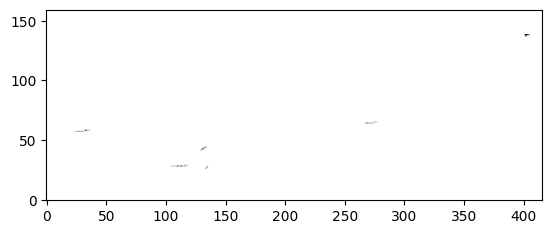

In [9]:
# plt.figure(figsize=(12, 6))
show_image(events_test)

In [10]:
# Rowise split into X batches
X_patches_batches = np.array(np.array_split(X_patches_adcs, BATCH_SIZE, axis=0))
X_patches_batches.shape

(3, 95539, 16)

In [11]:
# TODO: reconstruct part of the patches to see result
X_patches_fragment = X_patches_batches[0].reshape(-1, PATCH_SIZE, PATCH_SIZE)
X_patches_fragment.shape


(95539, 4, 4)

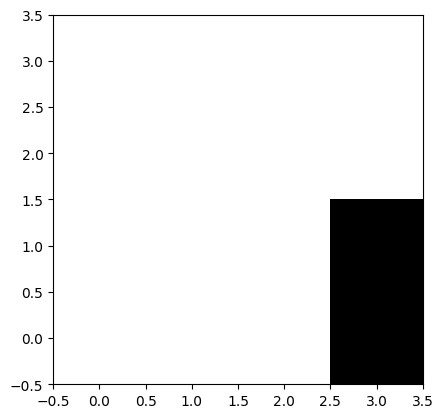

In [12]:
plot_patch(X_patches_fragment[0])

In [13]:
X_patches_batches = torch.tensor(X_patches_batches).unsqueeze(1).float()
transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Resize((PATCH_WIDTH, PATCH_HEIGHT)),
])
train_loader = DataLoader(dataset=X_patches_batches, batch_size=BATCH_SIZE, shuffle=True)

In [14]:
data_sample = next(iter(train_loader))
data_sample[0][0][0].shape

torch.Size([16])

In [15]:
class VQEmbedding(nn.Module):
    def __init__(self, num_embeddings, embedding_dim):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_embeddings = num_embeddings

        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.embedding.weight.data.uniform_(-1/self.num_embeddings, 1/self.num_embeddings)

    def forward(self, z):
        # b = batch size
        # c = number of channels
        # h = height
        # w = width
        b, c, h, w = z.shape
        z_channel_last = z.permute(0, 2, 3, 1)
        z_flattened = z_channel_last.reshape(b*h*w, self.embedding_dim)

        # Calculate distances between z and the codebook embeddings |a-b|²
        # Euclidean distance. Form applied for efficiency in deep learning. In literature l2 distance is used.
        distances = (
            torch.sum(z_flattened ** 2, dim=-1, keepdim=True)                 # a²
            + torch.sum(self.embedding.weight.t() ** 2, dim=0, keepdim=True)  # b²
            - 2 * torch.matmul(z_flattened, self.embedding.weight.t())        # -2ab
        )

        # Get the index with the smallest distance
        # Finds minimum indexes at each row. Uses nearest neigboor look up
        encoding_indices = torch.argmin(distances, dim=-1)

        # Get the quantized vector
        z_q = self.embedding(encoding_indices)
        # when we find the indexes feature vectors, we reshape them to the encoder latent 
        # representation shape
        z_q = z_q.reshape(b, h, w, self.embedding_dim)
        
        # changed the order of the reshaped z_q
        z_q = z_q.permute(0, 3, 1, 2)

        # Calculate the commitment loss
        # Measures how closely the encoder outputs and the selected codebook embeddings match each other.
        reconstruction_loss = F.mse_loss(z_q, z.detach())
        commitment_loss = F.mse_loss(z_q.detach(), z)
        loss = reconstruction_loss + beta * commitment_loss

        # Straight-through estimator trick for gradient backpropagation
        # Finding closer membership to indexes
        z_q = z + (z_q - z).detach()

        return z_q, loss, encoding_indices

In [16]:
class Residual(nn.Module):
    """
    Residual Convolutional Layer
    """

    def __init__(self, in_channels, num_hiddens, num_residual_hiddens):
        """
        initialize residual CNN layer

        :param in_channels number: Number of input channels
        :param num_hiddens number: Number of hidden channels
        :param num_residual_hiddens number: Number of residual hiddens
        """
        super(Residual, self).__init__()
        self._block = nn.Sequential(
            nn.ReLU(True),
            # C: 3 -> residual hidden
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=num_residual_hiddens,
                kernel_size=2,
                stride=1,
                padding=1,
                bias=False,
            ),
            nn.ReLU(True),
            # C: resiual hidden -> out_hidden
            nn.Conv2d(
                in_channels=num_residual_hiddens,
                out_channels=num_hiddens,
                kernel_size=2,
                stride=1,
                bias=False,
            ),
        )

    def forward(self, x):
        """
        Residual layer

        :param x numpy.ndarray: Input image
        """
        return x + self._block(x)  # residual output


class ResidualStack(nn.Module):
    """
    Residual Convolution Stack
    """

    def __init__(
        self, in_channels, num_hiddens, num_residual_layers, num_residual_hiddens
    ):
        """
        initialize residual stack

        :param in_channels number: Number of input channels
        :param num_hiddens number: Number of hidden channels
        :param num_residual_layers number: Number of residual layers in stack
        :param num_residual_hiddens number: Number of hidden residual channels
        """
        super(ResidualStack, self).__init__()
        self._num_residual_layers = num_residual_layers
        self._layers = nn.ModuleList(
            [
                Residual(in_channels, num_hiddens, num_residual_hiddens)
                for _ in range(self._num_residual_layers)
            ]
        )

    def forward(self, x):
        """
        Apply residual stack

        :param x numpy.ndarray: Input image
        """
        # Apply all residual layers in stack
        for i in range(self._num_residual_layers):
            x = self._layers[i](x)
        return F.relu(x)

In [17]:
class VQVAE(nn.Module):
    def __init__(self):
        super(VQVAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, 2, kernel_size=2, stride=1, padding=1),
            # ResidualStack(
            #     in_channels=16,
            #     num_hiddens=16,
            #     num_residual_layers=num_residual_layers,
            #     num_residual_hiddens=num_residual_hiddens,
            # ),
            nn.ReLU(),
            nn.Conv2d(2, 4, kernel_size=2, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(4, 8, kernel_size=2, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, latent_dim, kernel_size=1)
        )

        # Vector Quantization
        self.vq_layer = VQEmbedding(num_embeddings, latent_dim)
        
        self.vq_residual = ResidualStack(
            in_channels=latent_dim,
            num_hiddens=latent_dim,
            num_residual_layers=latent_dim,
            num_residual_hiddens=num_residual_hiddens,
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 8, kernel_size=1),
            # ResidualStack(
            #     in_channels=64,
            #     num_hiddens=64,
            #     num_residual_layers=num_residual_layers,
            #     num_residual_hiddens=num_residual_hiddens,
            # ),
            nn.ReLU(),
            nn.ConvTranspose2d(8, 4, kernel_size=2, stride=1, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(4, 2, kernel_size=2, stride=1, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(2, channels, kernel_size=2, stride=1, padding=1),
            nn.Tanh()  # Output values in range [-1, 1]
        )

    def forward(self, x):
        z_e = self.encoder(x)
        
        z_q, vq_loss, encodings = self.vq_layer(z_e)
        # print(f"Compressed shape: {z_q.shape}")
        
        # row level mean
        counts = torch.bincount(
            encodings,
            minlength=num_embeddings
        ).float()
        
        avg_probs = counts / counts.sum()
        perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10)))
        
        x_recon = self.decoder(z_q)
        return x_recon, vq_loss, perplexity

In [18]:
model = VQVAE().to(device)
optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

In [19]:
def _get_vq_loss(recon_x, x, vq_loss):
    recon_loss = F.mse_loss(recon_x, x)
    return recon_loss + vq_loss

Epoch 1/60: 100%|██████████| 1/1 [00:00<00:00,  4.96it/s, Loss=1.74e+3]

Printing before/after reconstruction


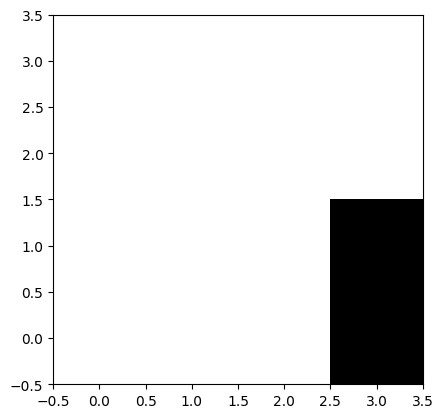

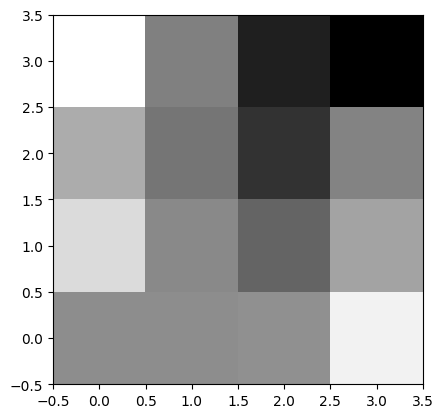

Epoch [1/60] Average Loss: 579.9354


Epoch 2/60: 100%|██████████| 1/1 [00:00<00:00, 17.41it/s, Loss=1.74e+3]


Epoch [2/60] Average Loss: 579.9200


Epoch 3/60: 100%|██████████| 1/1 [00:00<00:00, 17.30it/s, Loss=1.74e+3]


Epoch [3/60] Average Loss: 579.9737


...

Epoch [9/60] Average Loss: 580.3095


Epoch 10/60: 100%|██████████| 1/1 [00:00<00:00, 18.60it/s, Loss=1.74e+3]


Epoch [10/60] Average Loss: 580.1611


Epoch 11/60: 100%|██████████| 1/1 [00:00<00:00, 18.59it/s, Loss=1.74e+3]


Printing before/after reconstruction


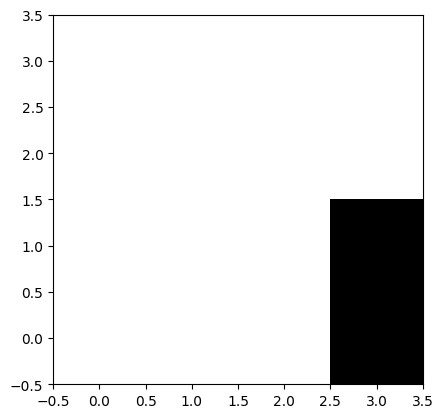

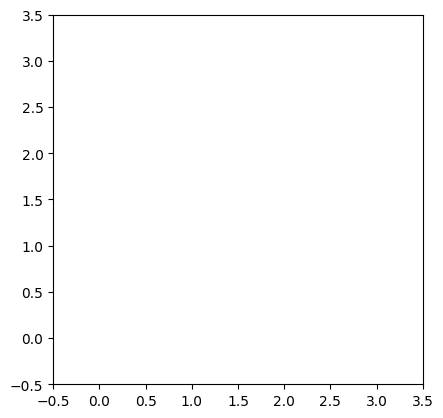

Epoch [11/60] Average Loss: 579.9782


Epoch 12/60: 100%|██████████| 1/1 [00:00<00:00, 18.45it/s, Loss=1.74e+3]


Epoch [12/60] Average Loss: 579.7778


Epoch 13/60: 100%|██████████| 1/1 [00:00<00:00, 18.66it/s, Loss=1.74e+3]


Epoch [13/60] Average Loss: 579.5720


...

Epoch [19/60] Average Loss: 578.5608


Epoch 20/60: 100%|██████████| 1/1 [00:00<00:00, 18.01it/s, Loss=1.74e+3]


Epoch [20/60] Average Loss: 578.4442


Epoch 21/60: 100%|██████████| 1/1 [00:00<00:00, 18.19it/s, Loss=1.74e+3]


Printing before/after reconstruction


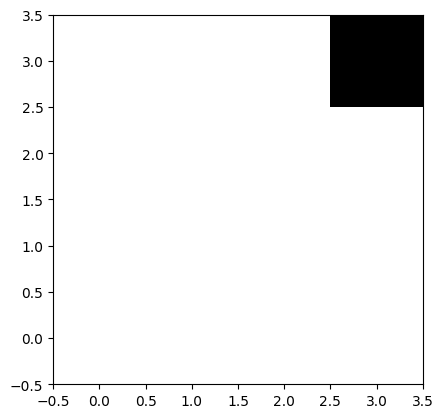

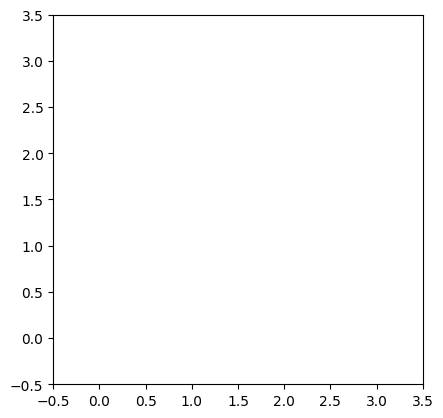

Epoch [21/60] Average Loss: 578.3402


Epoch 22/60: 100%|██████████| 1/1 [00:00<00:00, 18.21it/s, Loss=1.73e+3]


Epoch [22/60] Average Loss: 578.2474


Epoch 23/60: 100%|██████████| 1/1 [00:00<00:00, 18.56it/s, Loss=1.73e+3]


Epoch [23/60] Average Loss: 578.1636


...

Epoch [29/60] Average Loss: 577.7371


Epoch 30/60: 100%|██████████| 1/1 [00:00<00:00, 18.24it/s, Loss=1.73e+3]


Epoch [30/60] Average Loss: 577.6718


Epoch 31/60: 100%|██████████| 1/1 [00:00<00:00, 18.04it/s, Loss=1.73e+3]


Printing before/after reconstruction


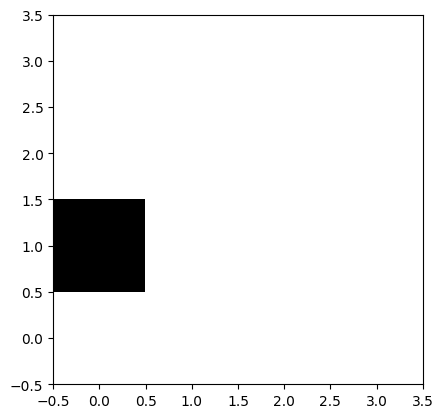

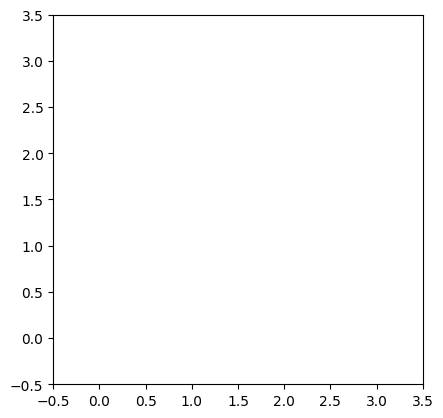

Epoch [31/60] Average Loss: 577.6083


Epoch 32/60: 100%|██████████| 1/1 [00:00<00:00, 17.71it/s, Loss=1.73e+3]


Epoch [32/60] Average Loss: 577.5469


Epoch 33/60: 100%|██████████| 1/1 [00:00<00:00, 17.81it/s, Loss=1.73e+3]


Epoch [33/60] Average Loss: 577.4878


...

Epoch [39/60] Average Loss: 577.1747


Epoch 40/60: 100%|██████████| 1/1 [00:00<00:00, 16.38it/s, Loss=1.73e+3]


Epoch [40/60] Average Loss: 577.1278


Epoch 41/60: 100%|██████████| 1/1 [00:00<00:00, 16.28it/s, Loss=1.73e+3]


Printing before/after reconstruction


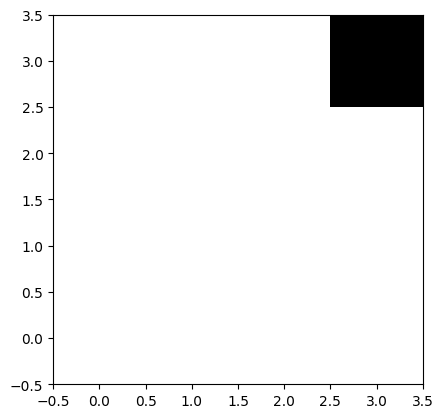

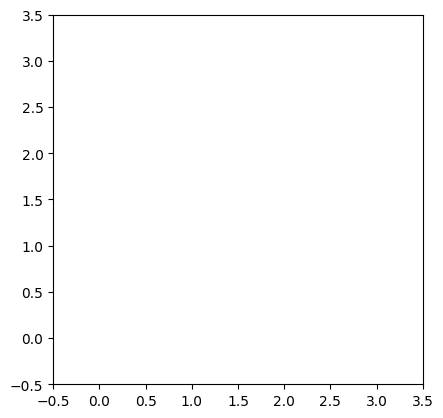

Epoch [41/60] Average Loss: 577.0819


Epoch 42/60: 100%|██████████| 1/1 [00:00<00:00, 16.04it/s, Loss=1.73e+3]


Epoch [42/60] Average Loss: 577.0370


Epoch 43/60: 100%|██████████| 1/1 [00:00<00:00, 16.14it/s, Loss=1.73e+3]


Epoch [43/60] Average Loss: 576.9930


...

Epoch [49/60] Average Loss: 576.4277


Epoch 50/60: 100%|██████████| 1/1 [00:00<00:00, 16.75it/s, Loss=1.73e+3]


Epoch [50/60] Average Loss: 576.2062


Epoch 51/60: 100%|██████████| 1/1 [00:00<00:00, 17.39it/s, Loss=1.73e+3]


Printing before/after reconstruction


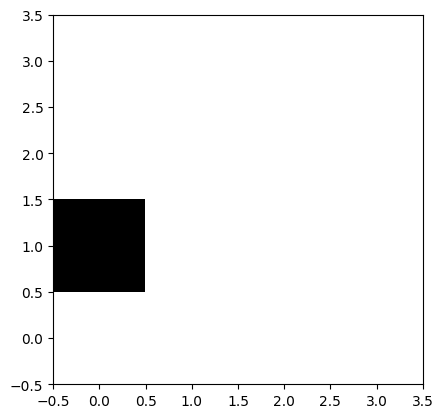

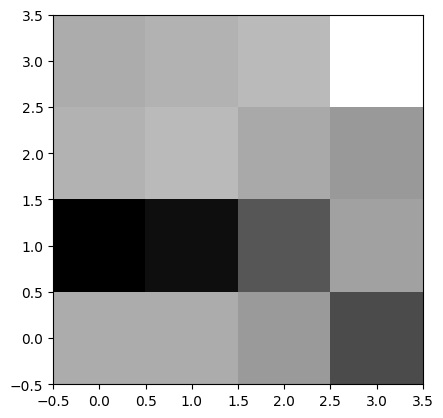

Epoch [51/60] Average Loss: 575.9674


Epoch 52/60: 100%|██████████| 1/1 [00:00<00:00, 17.35it/s, Loss=1.73e+3]


Epoch [52/60] Average Loss: 575.7466


Epoch 53/60: 100%|██████████| 1/1 [00:00<00:00, 18.10it/s, Loss=1.73e+3]


Epoch [53/60] Average Loss: 575.5850


...

Epoch [58/60] Average Loss: 580.3492


Epoch 59/60: 100%|██████████| 1/1 [00:00<00:00, 19.81it/s, Loss=1.75e+3]


Epoch [59/60] Average Loss: 583.0400


Epoch 60/60: 100%|██████████| 1/1 [00:00<00:00, 16.67it/s, Loss=1.76e+3]

Epoch [60/60] Average Loss: 585.6145


In [20]:
# TODO
# Try reading hit data. Create a matrix form which could be suitable for 
# VQ-VAE compression
# COmpress adcs values like with Kmeans. Find appropriate cendroids for adcs
# Do not use coordinates. They may be distort spatial values after reconstruction
# Try with one module hits

# loss
average_loss_values = []

# ssim
ssim_values = []

# perplexity
perplixty_values = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    # Use tqdm for the progress bar
    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f'Epoch {epoch+1}/{num_epochs}')

    for batch_idx, data in pbar:
        data = data.to(device)

        optimizer.zero_grad()
        recon_batch, vq_loss, perplexity = model(data)
    
        loss = _get_vq_loss(recon_batch, data, vq_loss)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()        

        # Update tqdm description with current loss
        pbar.set_postfix({'Loss': loss.item()})
    
    if epoch % 10 == 0:
        with torch.no_grad():
            print("Printing before/after reconstruction")
            patch_recon, _, _ = model(data)
            
            patch = data[0][0][0]
            plot_patch(patch.cpu().numpy())    
            
            patch_recon = patch_recon[0][0][0].cpu().numpy()
            plot_patch(patch_recon)
        

    avg_loss = train_loss / BATCH_SIZE
    average_loss_values.append(avg_loss)
    # perplixty_values.append(perplexity.cpu().numpy())
    
    print(f'Epoch [{epoch + 1}/{num_epochs}] Average Loss: {avg_loss:.4f}')

Printing average loss


/tmp/ipykernel_2348035/830922448.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


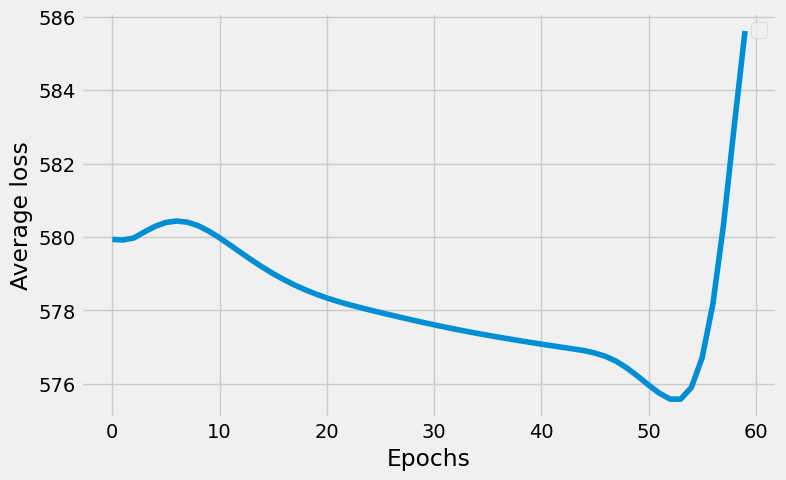

In [ ]:
epoch_values = list(range(num_epochs))

def plot_loss_results(loss: list[float], epochs: int) -> None:
    print("Printing average loss")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, loss)
    plt.xlabel('Epochs')
    plt.ylabel('Average loss')
    plt.legend()
    plt.show()

plot_loss_results(average_loss_values, epoch_values)

In [22]:
torch.save(model.state_dict(), "vq_vae_pileup.pth")

In [23]:
# Train model with unseen data
event_patches_adcs = [
    torch.tensor(
        event_hits_to_patches(event, PATCH_SIZE).as_array()
    ).float().unsqueeze(1).transpose(0, 1).unsqueeze(1)
    for event in events_test
]
print(f"Events test: {len(events_test)}")
print(f"Event patches: {len(event_patches_adcs[0])}")


Events test: 12
Event patches: 1


In [24]:
event_patches = [
    event_hits_to_patches(event, PATCH_SIZE)
    for event in events_test
]
event_patches = iter(event_patches)
event_test_first = next(event_patches)
event_test_first

PixelEventPatches(detector=<pileup_ml.detectors.pixels.PixelDetector object at 0x73b81f17e240>, patch_size=4, event_id=np.int32(10785001), det_ids=array([303042564, 303042564, 303042564, ..., 353338372, 353339396,
       353339396], shape=(10871,), dtype=uint32), rows=array([ 6,  7,  7, ..., 29, 23, 24], shape=(10871,), dtype=int32), cols=array([33, 26, 27, ..., 14, 15, 16], shape=(10871,), dtype=int32), adcs=array([[  0,   0,   0, ...,   0,  71,  89],
       [  0,  75,  56, ...,   0,   0,   0],
       [ 55,  62, 189, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ...,   0,  43,  88],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]],
      shape=(10871, 16), dtype=uint8), occupancy=array([[False, False, False, ..., False,  True,  True],
       [False,  True,  True, ..., False, False, False],
       [ True,  True,  True, ..., False, False, False],
       ...,
       [False, False, False, ..., False,  True,  True],
       [False, False, Fal

In [25]:
event_patches_adcs[0].shape

torch.Size([1, 1, 10871, 16])

Plotting test patch


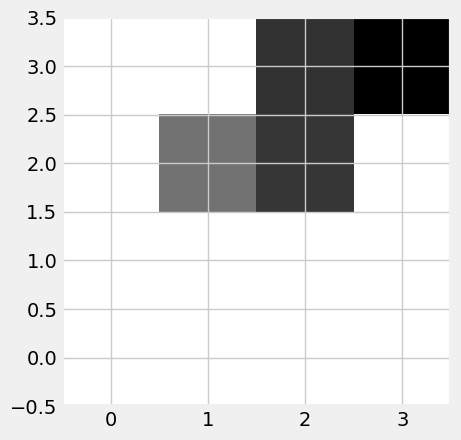

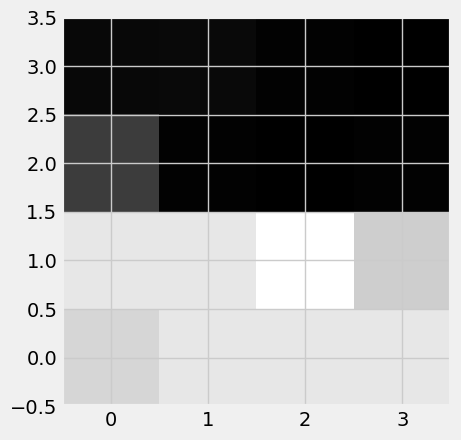

In [30]:
# testing with new data
event_patches = iter(event_patches_adcs)
model.load_state_dict(torch.load("vq_vae_pileup.pth"))
model = model.to(device)
model.eval()    

event_patches_decompressed = None
event_hits = None

with torch.no_grad():
    patches = next(event_patches)
    patches = patches.to(device)
    patches_batch, _, _ = model(patches)
    
    # Make the first decompressed event
    event_patches_decompressed = PixelEventPatches(
        detector=pix_det,
        patch_size=PATCH_SIZE,
        event_id=event_test_first.event_id,
        det_ids=event_test_first.det_ids,
        rows=event_test_first.rows,
        cols=event_test_first.cols,
        adcs=patches_batch.cpu().detach().numpy(),
        occupancy=np.arange(16)
    )
    event_hits = event_patches_to_hits(
        event_patches_decompressed
    )
    
    print("Plotting test patch")
    plot_patch(patches[0][0][0].cpu())
    plot_patch(patches_batch[0][0][0].cpu())

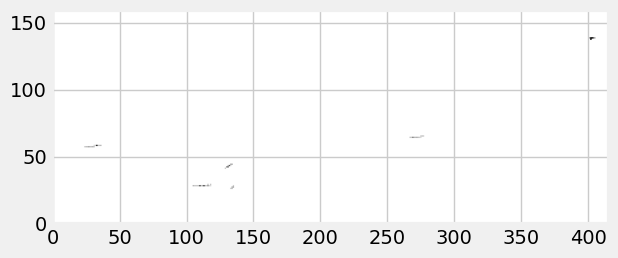

In [ ]:
# Plot reconstructed particle events after decompression
if event_hits:
    show_image(events_test)
    
# TODO: check SSIM metric value